# Nailfold Capillary Segmentation and Density Estimation Using U-Net

**Student:** Theodore Petrick Reimmer  
**Programme:** Master 1 VIBOT  
**University:** Université Bourgogne Europe  
**Project type:** Simplified biomedical deep learning implementation  

## Project idea

This notebook implements a simplified version of a biomedical image analysis pipeline inspired by:

> Bharathi et al., *A deep learning system for quantitative assessment of microvascular abnormalities in nailfold capillary images*, Rheumatology, 2023.

The objective is not to reproduce the complete clinical system exactly. The objective is to demonstrate the main technical workflow:

> nailfold image → preprocessing → U-Net segmentation → predicted mask → quantitative measurements → density estimation

## My point of view

This project helped me understand how medical AI systems are built from real image data. The model is not clinically reliable, but it demonstrates the important steps behind biomedical segmentation: using image-mask pairs, training a U-Net, generating overlays, extracting measurements, and interpreting results honestly.

# 1. Import Libraries

These libraries are used for image processing, deep learning, evaluation, visualization, and saving outputs.

In [1]:
import os
import zipfile
import random
import shutil
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# 2. Configuration

Put this notebook in the same folder as:

```text
Segmentation.zip
Density.zip
```

The notebook creates a working folder called:

```text
nailfold_work/
```

In [2]:
PROJECT_DIR = Path.cwd()

SEG_ZIP = PROJECT_DIR / "Segmentation.zip"
DENSITY_ZIP = PROJECT_DIR / "Density.zip"

WORK_DIR = PROJECT_DIR / "nailfold_work"
RAW_DIR = WORK_DIR / "raw"
PREPARED_DIR = WORK_DIR / "prepared"
OUTPUT_DIR = WORK_DIR / "outputs"

IMAGE_SIZE = 256
BATCH_SIZE = 4
EPOCHS = 20
LEARNING_RATE = 1e-4
THRESHOLD = 0.5
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cpu


# 3. Helper Functions

These functions create folders, unzip files, load images, clean masks, and generate overlays.

In [3]:
IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

def ensure_dir(path):
    path.mkdir(parents=True, exist_ok=True)

def list_images(folder):
    if not folder.exists():
        return []
    return sorted([p for p in folder.iterdir() if p.suffix.lower() in IMAGE_EXTS])

def unzip_if_needed(zip_path, output_dir):
    if zip_path.exists():
        ensure_dir(output_dir)
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(output_dir)
        print(f"Extracted: {zip_path.name}")
    else:
        print(f"ZIP not found: {zip_path.name}. If already extracted, this is okay.")

def load_grayscale(path, size=256):
    img = Image.open(path).convert("L")
    img = img.resize((size, size))
    return np.array(img).astype(np.float32) / 255.0

def load_binary_mask(path, size=256):
    mask = Image.open(path).convert("L")
    mask = mask.resize((size, size))
    arr = np.array(mask).astype(np.float32)
    return (arr > 127).astype(np.float32)

def clean_mask(mask01):
    mask = (mask01 > 0.5).astype(np.uint8)
    kernel = np.ones((3, 3), np.uint8)

    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    cleaned = np.zeros_like(mask)

    for label in range(1, num_labels):
        area = stats[label, cv2.CC_STAT_AREA]
        if area >= 20:
            cleaned[labels == label] = 1

    return cleaned

def make_overlay(gray01, mask01):
    base = (gray01 * 255).astype(np.uint8)
    base_bgr = cv2.cvtColor(base, cv2.COLOR_GRAY2BGR)
    mask = (mask01 > 0.5).astype(np.uint8)

    overlay = base_bgr.copy()
    overlay[mask == 1] = (0, 255, 0)

    return cv2.addWeighted(base_bgr, 0.65, overlay, 0.35, 0)

# 4. Prepare the Dataset

The professor provided two folders:

## Segmentation
Contains native nailfold images and binary masks. This is used for supervised U-Net training.

## Density
Contains native images, 1 mm scale images, and capillary-count annotations. This is used to evaluate density estimation.

In [4]:
ensure_dir(WORK_DIR)
ensure_dir(RAW_DIR)
ensure_dir(PREPARED_DIR)
ensure_dir(OUTPUT_DIR)

unzip_if_needed(SEG_ZIP, RAW_DIR)
unzip_if_needed(DENSITY_ZIP, RAW_DIR)

Extracted: Segmentation.zip
Extracted: Density.zip


# 5. Match Segmentation Images With Masks

The segmentation images are usually inside:

```text
seg_images/
```

The masks are usually inside:

```text
seg_masks/
```

Example:

```text
N22a.jpg       → image
N22amask.jpg   → mask
```

In [5]:
def find_folder_by_name(root, target_name):
    for p in root.rglob("*"):
        if p.is_dir() and p.name.lower() == target_name.lower():
            return p
    return None

seg_images_dir = find_folder_by_name(RAW_DIR, "seg_images")
seg_masks_dir = find_folder_by_name(RAW_DIR, "seg_masks")

print("Segmentation images folder:", seg_images_dir)
print("Segmentation masks folder:", seg_masks_dir)

if seg_images_dir is None or seg_masks_dir is None:
    raise FileNotFoundError("Could not find seg_images and seg_masks folders.")

image_paths = list_images(seg_images_dir)
pairs = []

for img_path in image_paths:
    expected_mask = seg_masks_dir / f"{img_path.stem}mask{img_path.suffix}"
    if expected_mask.exists():
        pairs.append((img_path, expected_mask))

print("Total segmentation image-mask pairs found:", len(pairs))
for img, mask in pairs[:5]:
    print(img.name, "->", mask.name)

Segmentation images folder: c:\Users\classemobile\Desktop\nailfaild_capilary_using deep_learning\nailfold_work\raw\Segmentation\seg_images
Segmentation masks folder: c:\Users\classemobile\Desktop\nailfaild_capilary_using deep_learning\nailfold_work\raw\Segmentation\seg_masks
Total segmentation image-mask pairs found: 70
N22a.jpg -> N22amask.jpg
N22b.jpg -> N22bmask.jpg
N22f.jpg -> N22fmask.jpg
N23a.jpg -> N23amask.jpg
N23b.jpg -> N23bmask.jpg


# 6. Train / Validation / Test Split

The data is divided into:

- training set,
- validation set,
- test set.

The test set is kept unseen during training so we can evaluate generalization.

In [6]:
random.shuffle(pairs)

n_total = len(pairs)
n_train = int(0.70 * n_total)
n_val = int(0.15 * n_total)

train_pairs = pairs[:n_train]
val_pairs = pairs[n_train:n_train+n_val]
test_pairs = pairs[n_train+n_val:]

print("Total:", n_total)
print("Train:", len(train_pairs))
print("Validation:", len(val_pairs))
print("Test:", len(test_pairs))

Total: 70
Train: 49
Validation: 10
Test: 11


# 7. Save Prepared Dataset

This creates the folder structure:

```text
nailfold_work/prepared/segmentation/train
nailfold_work/prepared/segmentation/val
nailfold_work/prepared/segmentation/test
```

In [7]:
def copy_pairs(pairs, split_name):
    img_out = PREPARED_DIR / "segmentation" / split_name / "images"
    mask_out = PREPARED_DIR / "segmentation" / split_name / "masks"

    ensure_dir(img_out)
    ensure_dir(mask_out)

    for img_path, mask_path in pairs:
        shutil.copy2(img_path, img_out / img_path.name)
        shutil.copy2(mask_path, mask_out / img_path.name)

copy_pairs(train_pairs, "train")
copy_pairs(val_pairs, "val")
copy_pairs(test_pairs, "test")

print("Prepared data saved to:", PREPARED_DIR / "segmentation")

Prepared data saved to: c:\Users\classemobile\Desktop\nailfaild_capilary_using deep_learning\nailfold_work\prepared\segmentation


# 8. Visualize One Image and Mask

This confirms that the image and ground-truth mask are correctly paired.

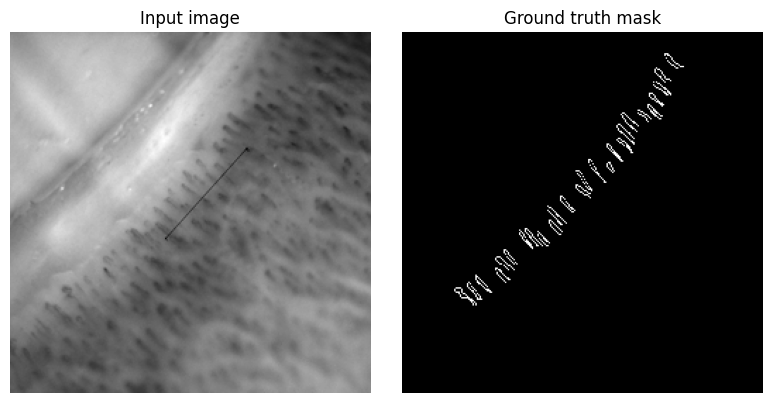

In [8]:
sample_img, sample_mask = train_pairs[0]

img = load_grayscale(sample_img, IMAGE_SIZE)
mask = load_binary_mask(sample_mask, IMAGE_SIZE)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img, cmap="gray")
plt.title("Input image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Ground truth mask")
plt.axis("off")

plt.tight_layout()
plt.show()

# 9. PyTorch Dataset Class

This class loads each image and mask during training.

In [9]:
class NailfoldSegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, size=256):
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.size = size
        self.images = list_images(self.image_dir)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        mask_path = self.mask_dir / img_path.name

        img = load_grayscale(img_path, self.size)
        mask = load_binary_mask(mask_path, self.size)

        img_tensor = torch.from_numpy(img).unsqueeze(0).float()
        mask_tensor = torch.from_numpy(mask).unsqueeze(0).float()

        return img_tensor, mask_tensor, img_path.name

# 10. U-Net Architecture

U-Net is a common model for biomedical segmentation.

Simple explanation:

- **Encoder:** extracts image features.
- **Bottleneck:** stores high-level compressed information.
- **Decoder:** reconstructs the segmentation mask.
- **Skip connections:** preserve fine details, which is important for small capillaries.

In [10]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base_channels=32):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, base_channels)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(base_channels, base_channels * 2)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(base_channels * 2, base_channels * 4)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(base_channels * 4, base_channels * 8)

        self.up3 = nn.ConvTranspose2d(base_channels * 8, base_channels * 4, 2, stride=2)
        self.dec3 = DoubleConv(base_channels * 8, base_channels * 4)

        self.up2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, 2, stride=2)
        self.dec2 = DoubleConv(base_channels * 4, base_channels * 2)

        self.up1 = nn.ConvTranspose2d(base_channels * 2, base_channels, 2, stride=2)
        self.dec1 = DoubleConv(base_channels * 2, base_channels)

        self.final = nn.Conv2d(base_channels, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        b = self.bottleneck(self.pool3(e3))

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)

# 11. Loss and Evaluation Metrics

The model uses:

- Binary Cross-Entropy loss,
- Dice loss,
- Dice score,
- IoU.

Dice and IoU measure how much the predicted mask overlaps with the ground-truth mask.

In [11]:
class DiceBCELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)

        probs = torch.sigmoid(logits)
        smooth = 1e-6

        intersection = (probs * targets).sum(dim=(1,2,3))
        union = probs.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3))

        dice_loss = 1 - ((2 * intersection + smooth) / (union + smooth)).mean()
        return bce_loss + dice_loss

def dice_score_from_masks(pred, target):
    pred = pred.astype(np.uint8)
    target = target.astype(np.uint8)
    intersection = np.logical_and(pred, target).sum()
    denom = pred.sum() + target.sum()
    return 1.0 if denom == 0 else (2 * intersection) / denom

def iou_score_from_masks(pred, target):
    pred = pred.astype(np.uint8)
    target = target.astype(np.uint8)
    intersection = np.logical_and(pred, target).sum()
    union = np.logical_or(pred, target).sum()
    return 1.0 if union == 0 else intersection / union

# 12. Train the U-Net

Training process:

1. The model receives a nailfold image.
2. It predicts a mask.
3. The prediction is compared with the ground-truth mask.
4. The model calculates the error.
5. The model updates its weights.
6. This repeats through epochs.

This is where the AI learns the vessel patterns.

In [12]:
train_dataset = NailfoldSegmentationDataset(
    PREPARED_DIR / "segmentation/train/images",
    PREPARED_DIR / "segmentation/train/masks",
    IMAGE_SIZE
)

val_dataset = NailfoldSegmentationDataset(
    PREPARED_DIR / "segmentation/val/images",
    PREPARED_DIR / "segmentation/val/masks",
    IMAGE_SIZE
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

model = UNet(in_channels=1, out_channels=1, base_channels=32).to(DEVICE)
criterion = DiceBCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

best_val_dice = 0.0
history = []

ensure_dir(OUTPUT_DIR)

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0

    for images, masks, _ in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} train"):
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0.0
    val_dices = []

    with torch.no_grad():
        for images, masks, _ in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} val"):
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            logits = model(images)
            loss = criterion(logits, masks)
            val_loss += loss.item()

            probs = torch.sigmoid(logits).cpu().numpy()
            true_masks = masks.cpu().numpy()

            for p, t in zip(probs, true_masks):
                pred = (p.squeeze() > THRESHOLD).astype(np.uint8)
                target = (t.squeeze() > 0.5).astype(np.uint8)
                val_dices.append(dice_score_from_masks(pred, target))

    val_loss /= len(val_loader)
    val_dice = float(np.mean(val_dices))

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_dice": val_dice
    })

    print(f"Epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, val_dice={val_dice:.4f}")

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), OUTPUT_DIR / "unet_best.pth")
        print("Saved best model.")

print("Training complete.")

Epoch 1/20 val: 100%|██████████| 3/3 [00:01<00:00,  2.22it/s]


Epoch 1: train_loss=1.7855, val_loss=1.7657, val_dice=0.0218
Saved best model.


Epoch 2/20 val: 100%|██████████| 3/3 [00:01<00:00,  2.49it/s]


Epoch 2: train_loss=1.7105, val_loss=1.6888, val_dice=0.0208


Epoch 3/20 val: 100%|██████████| 3/3 [00:03<00:00,  1.27s/it]


...

Epoch 18: train_loss=1.4799, val_loss=1.4746, val_dice=0.0099


Epoch 19/20 val: 100%|██████████| 3/3 [00:01<00:00,  2.67it/s]


Epoch 19: train_loss=1.4693, val_loss=1.4610, val_dice=0.0114


Epoch 20/20 val: 100%|██████████| 3/3 [00:01<00:00,  2.69it/s]

Epoch 20: train_loss=1.4602, val_loss=1.4552, val_dice=0.0059
Training complete.


# 13. Plot Training Curve

This plot shows training and validation loss across epochs.

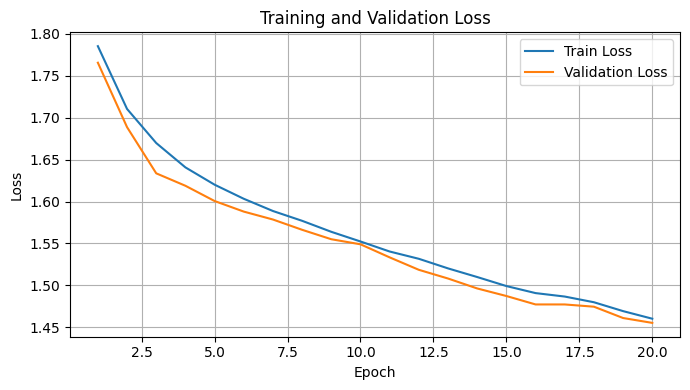

In [13]:
history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / "training_history.csv", index=False)

plt.figure(figsize=(7,4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_loss_curve.png", dpi=200)
plt.show()

# 14. Test Prediction

The best saved model is tested on images that were not used during training.

In [14]:
test_dataset = NailfoldSegmentationDataset(
    PREPARED_DIR / "segmentation/test/images",
    PREPARED_DIR / "segmentation/test/masks",
    IMAGE_SIZE
)

test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

model.load_state_dict(torch.load(OUTPUT_DIR / "unet_best.pth", map_location=DEVICE))
model.eval()

seg_out_dir = OUTPUT_DIR / "segmentation_test"
mask_out_dir = seg_out_dir / "predicted_masks"
overlay_out_dir = seg_out_dir / "overlays"

ensure_dir(mask_out_dir)
ensure_dir(overlay_out_dir)

test_results = []

with torch.no_grad():
    for images, masks, names in tqdm(test_loader, desc="Testing"):
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        logits = model(images)
        probs = torch.sigmoid(logits).cpu().numpy()[0,0]

        pred_mask = (probs > THRESHOLD).astype(np.float32)
        pred_mask = clean_mask(pred_mask)

        true_mask = masks.cpu().numpy()[0,0]
        true_mask_bin = (true_mask > 0.5).astype(np.uint8)

        dice = dice_score_from_masks(pred_mask, true_mask_bin)
        iou = iou_score_from_masks(pred_mask, true_mask_bin)

        gray = images.cpu().numpy()[0,0]
        overlay = make_overlay(gray, pred_mask)

        name = names[0]
        cv2.imwrite(str(mask_out_dir / f"{Path(name).stem}_mask.png"), (pred_mask * 255).astype(np.uint8))
        cv2.imwrite(str(overlay_out_dir / f"{Path(name).stem}_overlay.png"), overlay)

        test_results.append({"image": name, "dice": dice, "iou": iou})

test_df = pd.DataFrame(test_results)
test_df.to_csv(seg_out_dir / "segmentation_test_results.csv", index=False)

print(test_df)
print("Mean Dice:", test_df["dice"].mean())
print("Mean IoU:", test_df["iou"].mean())

Testing: 100%|██████████| 11/11 [00:01<00:00,  7.36it/s]

       image      dice       iou
0   N23a.jpg  0.000000  0.000000
1   N24c.jpg  0.000000  0.000000
2   N25c.jpg  0.075000  0.038961
3   N26b.jpg  0.041253  0.021061
4   N27e.jpg  0.000000  0.000000
5   N28c.jpg  0.000000  0.000000
6   N29c.jpg  0.000000  0.000000
7   N29d.jpg  0.007306  0.003666
8   N30g.jpg  0.143556  0.077329
9   N31b.jpg  0.000000  0.000000
10  N32e.jpg  0.039749  0.020277
Mean Dice: 0.027896730492500636
Mean IoU: 0.014663124600305694


# 15. Visualize Segmentation Results

Green regions show predicted capillary/vessel areas.

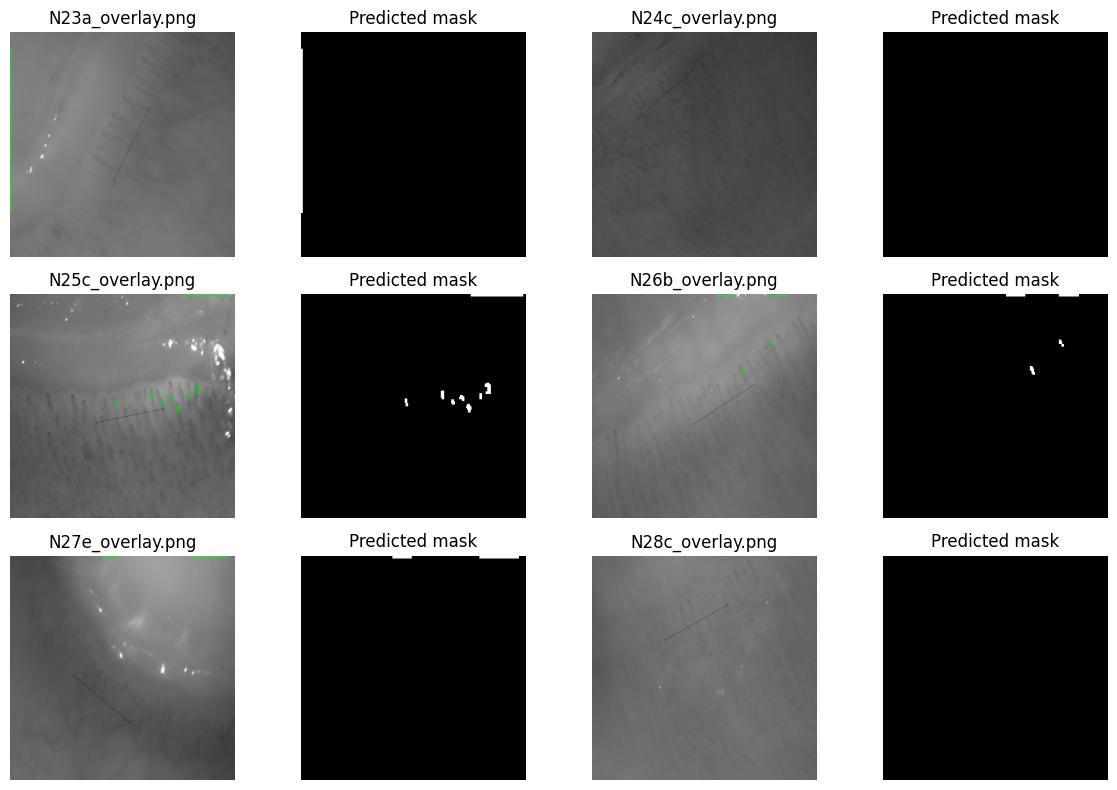

In [15]:
overlay_files = sorted(list((OUTPUT_DIR / "segmentation_test/overlays").glob("*.png")))[:6]
mask_files = sorted(list((OUTPUT_DIR / "segmentation_test/predicted_masks").glob("*.png")))[:6]

plt.figure(figsize=(12, 8))

for i, (overlay_path, mask_path) in enumerate(zip(overlay_files, mask_files)):
    overlay = cv2.cvtColor(cv2.imread(str(overlay_path)), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    plt.subplot(3, 4, 2*i + 1)
    plt.imshow(overlay)
    plt.title(overlay_path.name)
    plt.axis("off")

    plt.subplot(3, 4, 2*i + 2)
    plt.imshow(mask, cmap="gray")
    plt.title("Predicted mask")
    plt.axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "segmentation_examples_grid.png", dpi=200)
plt.show()

# 16. Measurement Extraction

After segmentation, the predicted mask is used to calculate:

- component count,
- mean width,
- maximum width,
- density per 100 pixels,
- shape score.

These are simplified quantitative features inspired by the article.

In [16]:
def skeletonize_binary(mask):
    img = (mask > 0).astype(np.uint8) * 255
    skel = np.zeros(img.shape, np.uint8)
    element = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))

    while True:
        opened = cv2.morphologyEx(img, cv2.MORPH_OPEN, element)
        temp = cv2.subtract(img, opened)
        eroded = cv2.erode(img, element)
        skel = cv2.bitwise_or(skel, temp)
        img = eroded.copy()
        if cv2.countNonZero(img) == 0:
            break

    return (skel > 0).astype(np.uint8)

def extract_measurements(mask01):
    mask = clean_mask(mask01)
    vessel_area_px = int(mask.sum())

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    component_count = max(num_labels - 1, 0)

    if vessel_area_px == 0 or component_count == 0:
        return {
            "component_count": 0,
            "mean_width_px": 0.0,
            "max_width_px": 0.0,
            "density_per_100px": 0.0,
            "shape_score": 0.0
        }

    ys, xs = np.where(mask > 0)
    horizontal_span = max(xs.max() - xs.min() + 1, 1)
    density_per_100px = component_count / horizontal_span * 100.0

    dist = cv2.distanceTransform(mask.astype(np.uint8), cv2.DIST_L2, 5)
    skeleton = skeletonize_binary(mask)
    widths = dist[skeleton > 0] * 2.0

    mean_width = float(np.mean(widths)) if len(widths) > 0 else 0.0
    max_width = float(np.max(widths)) if len(widths) > 0 else 0.0

    contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    shape_scores = []

    for c in contours:
        area = cv2.contourArea(c)
        if area < 20:
            continue
        perimeter = cv2.arcLength(c, True)
        x, y, w, h = cv2.boundingRect(c)
        diagonal = np.sqrt(w**2 + h**2)
        if diagonal > 0:
            shape_scores.append(perimeter / diagonal)

    shape_score = float(np.mean(shape_scores)) if shape_scores else 0.0

    return {
        "component_count": component_count,
        "mean_width_px": mean_width,
        "max_width_px": max_width,
        "density_per_100px": float(density_per_100px),
        "shape_score": shape_score
    }

# 17. Apply Measurements to Test Predictions

In [17]:
measurement_rows = []

for mask_path in sorted(mask_out_dir.glob("*.png")):
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    mask01 = (mask > 127).astype(np.float32)

    measurements = extract_measurements(mask01)
    measurements["image"] = mask_path.name.replace("_mask.png", ".jpg")
    measurement_rows.append(measurements)

measurement_df = pd.DataFrame(measurement_rows)
measurement_df.to_csv(seg_out_dir / "segmentation_measurements.csv", index=False)

measurement_df.head()

,component_count,mean_width_px,max_width_px,density_per_100px,shape_score,image
0,1,3.978610,4.0,50.000000,1.999886,N23a.jpg
1,0,0.000000,0.0,0.000000,0.000000,N24c.jpg
2,8,5.075649,8.0,5.925926,2.195699,N25c.jpg
3,4,5.499828,8.0,4.819277,2.129328,N26b.jpg
4,2,7.283582,8.0,1.388889,2.113655,N27e.jpg


# 18. Density Evaluation

The density task compares predicted counts with provided capillary-count annotations.

If the main script already created:

```text
nailfold_work/outputs/density/density_results.csv
```

this notebook will load it directly.

In [18]:
density_results_path = OUTPUT_DIR / "density/density_results.csv"

if density_results_path.exists():
    density_df = pd.read_csv(density_results_path)
    print("Loaded density results:")
    display(density_df.head())
else:
    print("No density results CSV found yet.")
    print("Run the .py script first if you want the full density evaluation.")

Loaded density results:


,image_id,native_image,scale_image,gt_count,predicted_component_count,absolute_count_error,gt_density_per_mm,pred_density_per_100px,estimated_scale_px_per_mm,mean_width_px,max_width_px,shape_score
0,N1a,nailfold_work\raw\Density\DATA\N1\N1a_Natif.jpg,nailfold_work\raw\Density\DATA\N1\N1a.jpg,6,1,5,6.0,0.390625,212.602916,8.635820,15.981400,2.817379
1,N1b,nailfold_work\raw\Density\DATA\N1\N1b_Natif.jpg,nailfold_work\raw\Density\DATA\N1\N1b.jpg,7,1,6,7.0,0.390625,384.011719,7.913875,33.168995,4.243493
2,N1c,nailfold_work\raw\Density\DATA\N1\N1c_Natif.jpg,nailfold_work\raw\Density\DATA\N1\N1c.jpg,9,1,8,9.0,0.390625,387.824703,10.420709,46.350391,2.885680
3,N1d,nailfold_work\raw\Density\DATA\N1\N1d_Natif.jpg,nailfold_work\raw\Density\DATA\N1\N1d.jpg,8,1,7,8.0,0.390625,384.192660,7.551274,35.150394,2.817379
4,N1e,nailfold_work\raw\Density\DATA\N1\N1e_Natif.jpg,nailfold_work\raw\Density\DATA\N1\N1e.jpg,8,11,3,8.0,4.296875,304.803215,9.540546,43.937992,2.971219


# 19. Plot Density Results

This cell tries to plot predicted count against ground-truth count if the columns are available.

Columns: ['image_id', 'native_image', 'scale_image', 'gt_count', 'predicted_component_count', 'absolute_count_error', 'gt_density_per_mm', 'pred_density_per_100px', 'estimated_scale_px_per_mm', 'mean_width_px', 'max_width_px', 'shape_score']


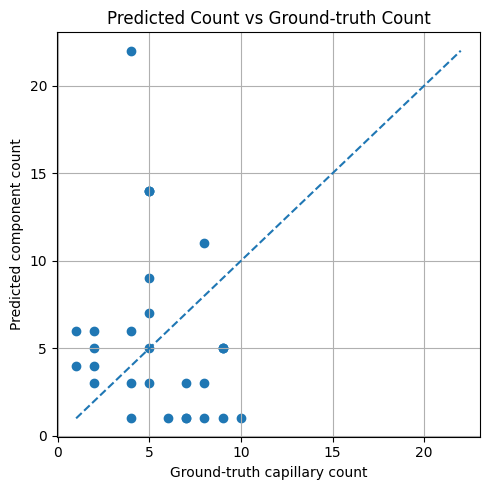

Mean Absolute Count Error: 4.896551724137931


In [21]:
if density_results_path.exists():
    density_df = pd.read_csv(density_results_path)

    print("Columns:", density_df.columns.tolist())

    gt_col = "gt_count"
    pred_col = "predicted_component_count"

    plt.figure(figsize=(5, 5))
    plt.scatter(density_df[gt_col], density_df[pred_col])

    mn = min(density_df[gt_col].min(), density_df[pred_col].min())
    mx = max(density_df[gt_col].max(), density_df[pred_col].max())

    plt.plot([mn, mx], [mn, mx], linestyle="--")
    plt.xlabel("Ground-truth capillary count")
    plt.ylabel("Predicted component count")
    plt.title("Predicted Count vs Ground-truth Count")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "density_scatter.png", dpi=200)
    plt.show()

    mae = density_df["absolute_count_error"].mean()
    print("Mean Absolute Count Error:", mae)
else:
    print("No density results CSV found yet.")

# 20. Final Output Summary

The main outputs are saved inside:

```text
nailfold_work/outputs/
```

In [22]:
print("Output files:")
for p in OUTPUT_DIR.rglob("*"):
    if p.is_file():
        print(p.relative_to(PROJECT_DIR))

Output files:
nailfold_work\outputs\.gitignore
nailfold_work\outputs\density_scatter.png
nailfold_work\outputs\segmentation_examples_grid.png
nailfold_work\outputs\training_history.csv
nailfold_work\outputs\training_loss_curve.png
nailfold_work\outputs\unet_best.pth
nailfold_work\outputs\density\density_results.csv
nailfold_work\outputs\segmentation_test\segmentation_measurements.csv
nailfold_work\outputs\segmentation_test\segmentation_test_results.csv
nailfold_work\outputs\segmentation_test\overlays\N23a_overlay.png
nailfold_work\outputs\segmentation_test\overlays\N24c_overlay.png
nailfold_work\outputs\segmentation_test\overlays\N25c_overlay.png
nailfold_work\outputs\segmentation_test\overlays\N26b_overlay.png
nailfold_work\outputs\segmentation_test\overlays\N27e_overlay.png
nailfold_work\outputs\segmentation_test\overlays\N28c_overlay.png
nailfold_work\outputs\segmentation_test\overlays\N29c_overlay.png
nailfold_work\outputs\segmentation_test\overlays\N29d_overlay.png
nailfold_work\o

# 21. Discussion

## What worked

The notebook demonstrates a full biomedical AI workflow:

- dataset preparation,
- image-mask pairing,
- U-Net training,
- segmentation prediction,
- overlay generation,
- Dice and IoU evaluation,
- measurement extraction,
- density evaluation.

## What was limited

The segmentation accuracy was low. This is expected because:

- the dataset is small,
- the model is simplified,
- training was short,
- CPU training limits experimentation,
- nailfold capillaries are thin and difficult to segment,
- the original paper used additional stages such as ResNet34 and logistic regression.

## My honest interpretation

This is not a clinical system. It is a correct educational implementation showing how a deep learning segmentation pipeline is built and evaluated.

# 22. Conclusion

This notebook implemented a simplified deep learning system for nailfold capillary segmentation and density estimation.

The final workflow is:

```text
medical image → preprocessing → U-Net → predicted mask → measurements → density estimation
```

Even though the accuracy was limited, the notebook shows the full process of biomedical image analysis using deep learning.

This also prepares me for future medical imaging projects, such as MRI tumour segmentation, where the same supervised image-mask idea can be applied.

# 23. References

1. P. G. Bharathi et al., “A deep learning system for quantitative assessment of microvascular abnormalities in nailfold capillary images,” *Rheumatology*, 2023.

2. O. Ronneberger, P. Fischer, and T. Brox, “U-Net: Convolutional Networks for Biomedical Image Segmentation,” MICCAI, 2015.

3. K. He, X. Zhang, S. Ren, and J. Sun, “Deep Residual Learning for Image Recognition,” CVPR, 2016.

4. L. Zhao et al., “A Comprehensive Dataset and Automated Pipeline for Nailfold Capillary Analysis,” 2023.